# Spaceship Titanic 분류 프로젝트

## 목차

1. 프로젝트 개요  
2. 데이터 불러오기 및 기본 확인  
3. 결측값 분석  
4. 타겟 분포 확인  
5. 범주형 피처 분석  
6. 수치형 피처 분석  
7. 피처 간 관계 분석  
8. 데이터 전처리 및 피처 엔지니어링  
9. 모델 학습 및 평가  
10. 예측 및 제출  
11. Summary  
12. 회고  
13. 확률 개선

## 1. 프로젝트 목표

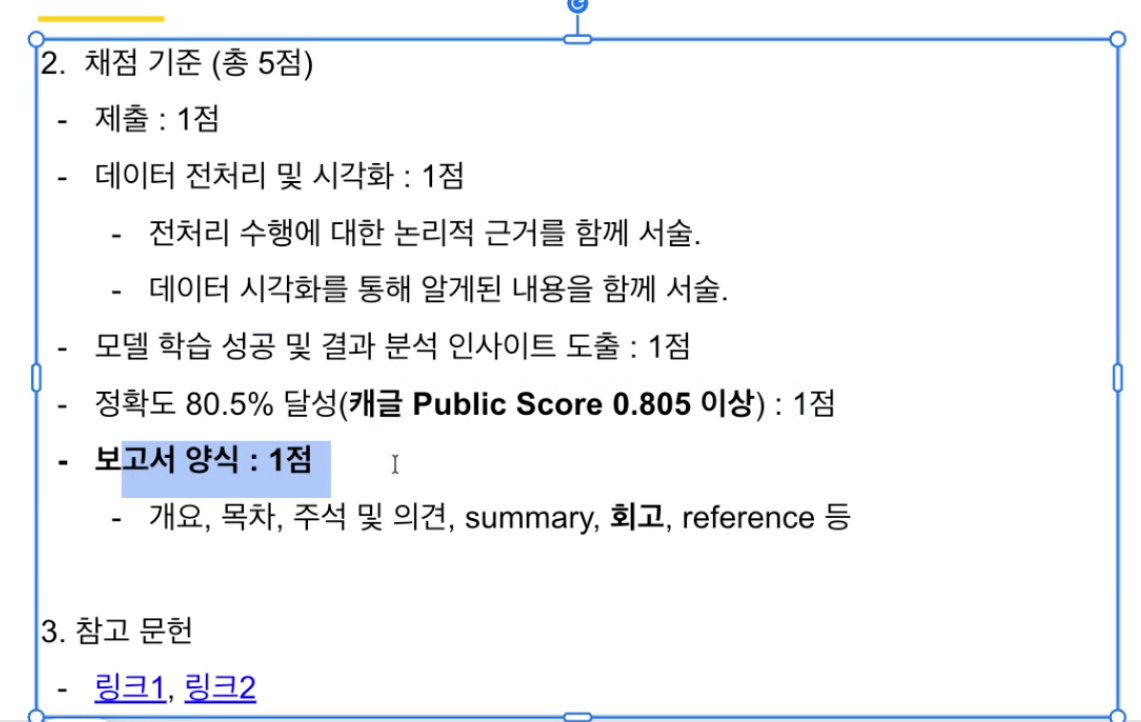

## 2. 데이터 불러오기 및 기본 확인

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print('train shape:', train.shape)
print('test shape:', test.shape)
train.head()

train shape: (8693, 14)
test shape: (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [2]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


train 데이터는 8693개 행, 14개 컬럼으로 구성되어 있다.  
test는 4277개 행이다.  
피처 타입을 보면 수치형(Age, RoomService, FoodCourt, ShoppingMall, Spa, VRDeck)과  
범주형(HomePlanet, CryoSleep, Cabin, Destination, VIP)이 섞여 있다.  
CryoSleep과 VIP는 bool 값인데 object 타입으로 읽혀서 전처리 시 변환이 필요하다.  
PassengerId는 XXXX_YY 형식인데 앞자리가 그룹 번호, 뒷자리가 그룹 내 순서다.


In [3]:
train.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


수치형 피처의 분포를 보면 RoomService, Spa, VRDeck 같은 지출 관련 컬럼은  

중앙값이 0이고 평균이 200~700 사이인 극도로 오른쪽으로 치우친 분포를 보인다.  

소수 승객이 아주 많이 지출하는 구조다.  

Age는 0~79세로 꽤 넓게 분포되어 있다.

## 3. 결측값 분석

In [4]:
missing = train.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(2)
missing_df = pd.DataFrame({'결측 수': missing, '결측 비율(%)': missing_pct})
missing_df[missing_df['결측 수'] > 0]

,결측 수,결측 비율(%)
CryoSleep,217,2.50
ShoppingMall,208,2.39
VIP,203,2.34
HomePlanet,201,2.31
Name,200,2.30
Cabin,199,2.29
VRDeck,188,2.16
Spa,183,2.11
FoodCourt,183,2.11
Destination,182,2.09


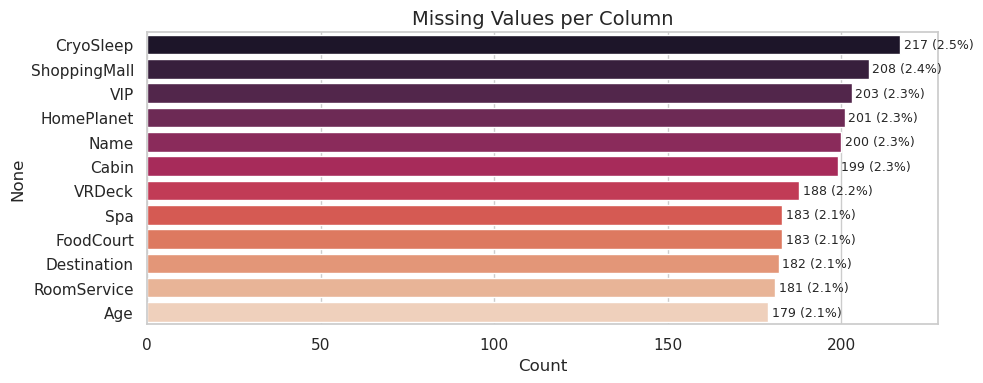

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
missing_only = missing[missing > 0]
colors = sns.color_palette('rocket', len(missing_only))
sns.barplot(x=missing_only.values, y=missing_only.index, palette='rocket', ax=ax)
ax.set_title('Missing Values per Column', fontsize=14)
ax.set_xlabel('Count')
for i, v in enumerate(missing_only.values):
    ax.text(v + 1, i, f'{v} ({v/len(train)*100:.1f}%)', va='center', fontsize=9)
plt.tight_layout()
plt.show()

Transported와 PassengerId를 제외한 거의 모든 컬럼에 결측값이 있다.  
결측 비율은 대부분 2~2.5% 수준으로 치명적이지는 않다.  
하지만 피처가 많고 결측이 여러 곳에 퍼져 있어서 단순히 행을 제거하면 꽤 많은 데이터를 잃는다.  
PassengerId의 그룹 정보를 활용하면 HomePlanet이나 Cabin 같은 컬럼의 결측을  
같은 그룹 내 다른 승객 정보로 채울 수 있다는 아이디어를 얻었다.  
이 방법을 전처리에서 적극 활용할 예정이다.


## 4. 타겟 분포 확인

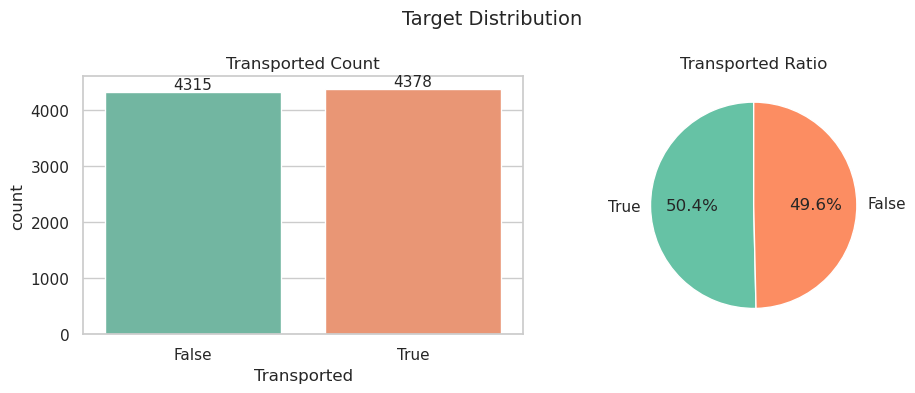

In [6]:
transported_counts = train['Transported'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(data=train, x='Transported', palette='Set2', ax=axes[0])
axes[0].set_title('Transported Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=11)

axes[1].pie(transported_counts.values,
            labels=['True', 'False'],
            autopct='%1.1f%%',
            colors=['#66c2a5', '#fc8d62'],
            startangle=90)
axes[1].set_title('Transported Ratio')

plt.suptitle('Target Distribution', fontsize=14)
plt.tight_layout()
plt.show()

True 4378명(50.3%), False 4315명(49.7%)으로 거의 정확히 반반이다.  
클래스 불균형이 없기 때문에 오버샘플링 같은 추가 처리는 필요 없다.  
단순히 모두 True라고 찍으면 50.3% 정확도가 나온다는 뜻이니, 이게 우리의 최소 기준점이다.


## 5. 범주형 피처 분석

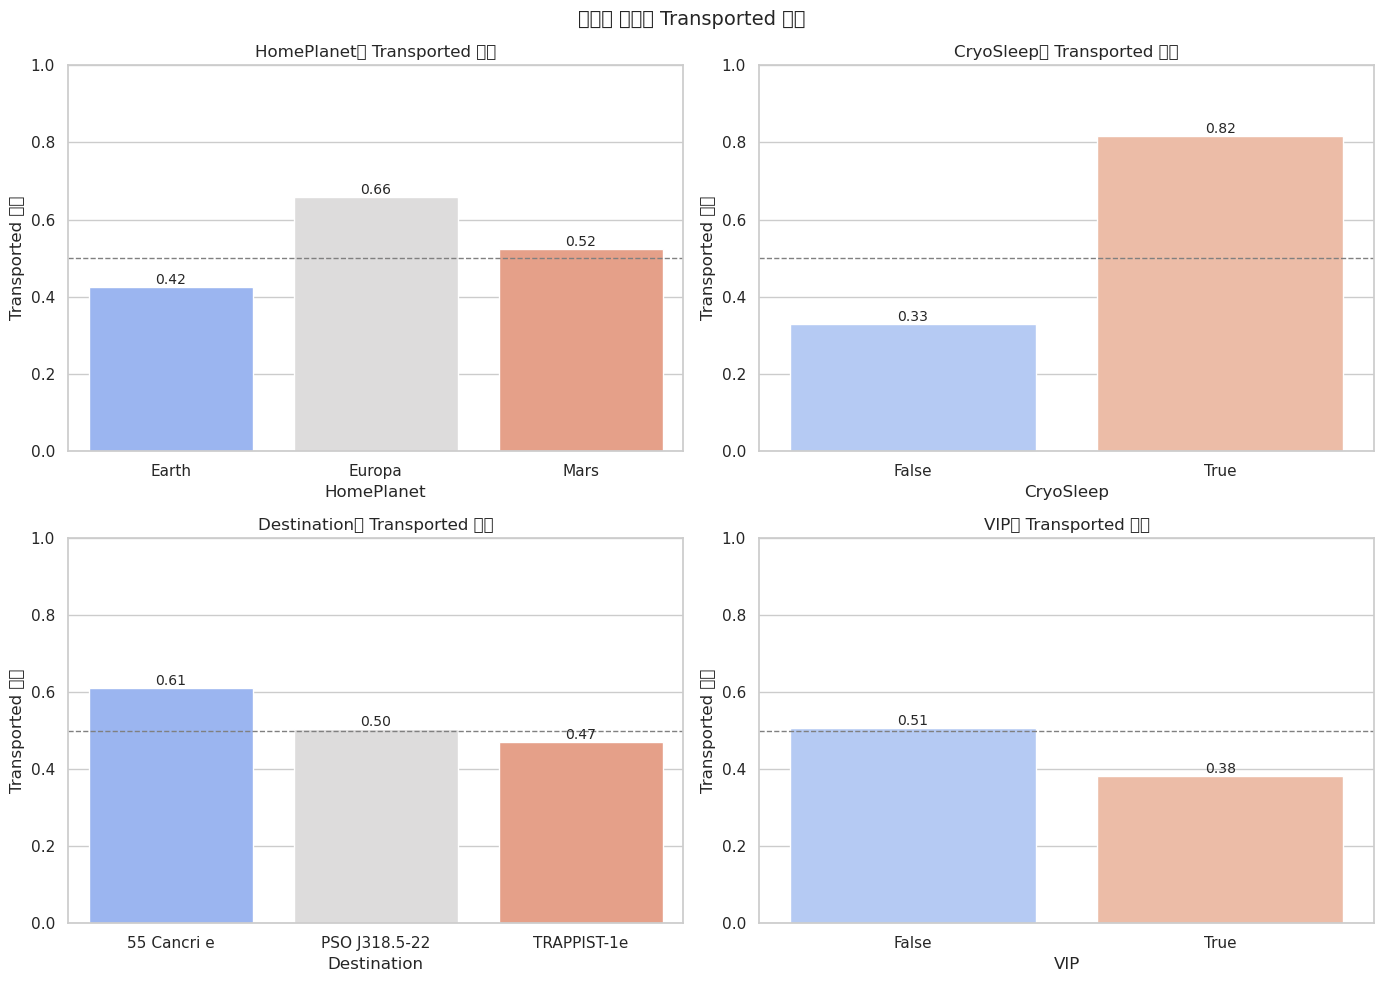

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cat_features = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']
titles = ['HomePlanet별 Transported 비율', 'CryoSleep별 Transported 비율',
          'Destination별 Transported 비율', 'VIP별 Transported 비율']

for ax, feat, title in zip(axes.flatten(), cat_features, titles):
    df_plot = train.groupby(feat)['Transported'].mean().reset_index()
    df_plot.columns = [feat, 'Transported_Rate']
    sns.barplot(data=df_plot, x=feat, y='Transported_Rate', palette='coolwarm', ax=ax)
    ax.set_title(title)
    ax.set_ylabel('Transported 비율')
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=10)

plt.suptitle('범주형 피처별 Transported 비율', fontsize=14)
plt.tight_layout()
plt.show()

HomePlanet을 보면 Europa 출신 승객의 순간이동 비율이 66%로 가장 높다.  
Earth 출신은 42%로 가장 낮다. 출발 행성이 순간이동과 유의미한 관련이 있다.  

CryoSleep이 가장 강력한 피처다. 동면 중인 승객은 82%가 순간이동됐고  
깨어 있던 승객은 33%만 순간이동됐다. 거의 2.5배 차이가 난다.  
CryoSleep 여부가 순간이동에 결정적인 영향을 준다는 걸 알 수 있다.  

VIP 승객은 오히려 순간이동 비율이 38%로 낮다. 일반 승객(50.6%)보다 훨씬 낮다.  
VIP 구역이 이상 현상에서 어느 정도 보호됐을 가능성이 있다.


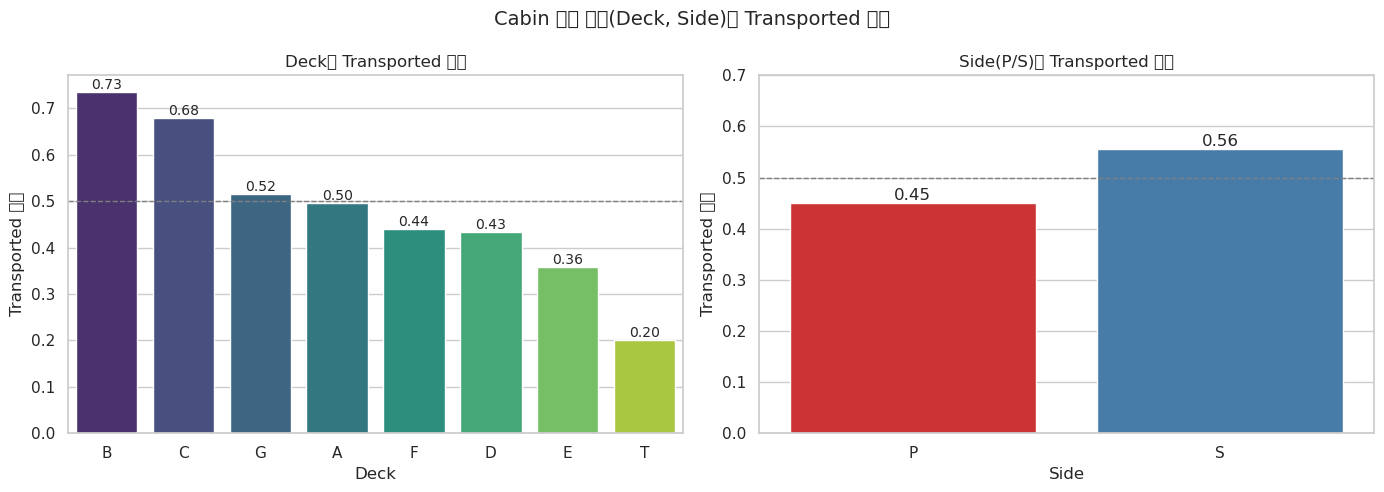

In [8]:
train['Deck'] = train['Cabin'].str.split('/').str[0]
train['Side'] = train['Cabin'].str.split('/').str[2]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

deck_df = train.groupby('Deck')['Transported'].mean().reset_index().sort_values('Transported', ascending=False)
sns.barplot(data=deck_df, x='Deck', y='Transported', palette='viridis', ax=axes[0])
axes[0].set_title('Deck별 Transported 비율')
axes[0].set_ylabel('Transported 비율')
axes[0].axhline(0.5, color='gray', linestyle='--', linewidth=1)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.2f}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

side_df = train.groupby('Side')['Transported'].mean().reset_index()
sns.barplot(data=side_df, x='Side', y='Transported', palette='Set1', ax=axes[1])
axes[1].set_title('Side(P/S)별 Transported 비율')
axes[1].set_ylabel('Transported 비율')
axes[1].set_ylim(0, 0.7)
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.2f}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=12)

plt.suptitle('Cabin 파생 피처(Deck, Side)별 Transported 비율', fontsize=14)
plt.tight_layout()
plt.show()

Cabin 컬럼을 Deck/CabinNum/Side로 파싱했더니 유용한 정보가 나왔다.  

Deck B와 C는 순간이동 비율이 각각 73%, 68%로 아주 높다.  
반면 E(36%), T(20%)는 낮다. 우주선 내부 위치가 이상 현상 영향을 받은 구역과 연관이 있어 보인다.  

Side는 P(좌현)가 45%, S(우현)가 56%로 우현 쪽 승객이 더 많이 순간이동됐다.  
미묘한 차이지만 피처로 활용할 수 있다.


## 6. 수치형 피처 분석

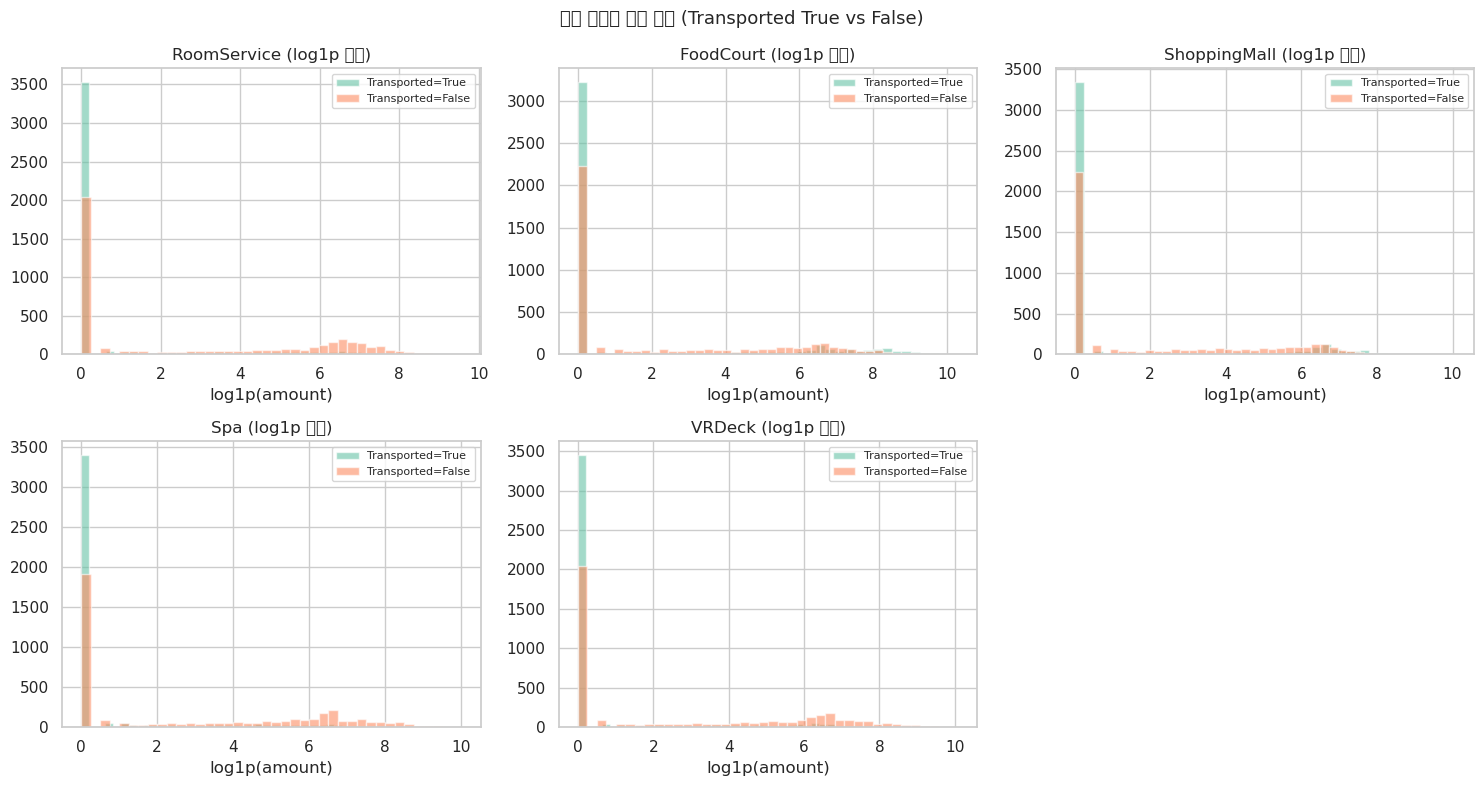

In [9]:
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(spend_cols):
    data_t = train[train['Transported'] == True][col].dropna()
    data_f = train[train['Transported'] == False][col].dropna()
    
    axes[i].hist(np.log1p(data_t), bins=40, alpha=0.6, label='Transported=True', color='#66c2a5')
    axes[i].hist(np.log1p(data_f), bins=40, alpha=0.6, label='Transported=False', color='#fc8d62')
    axes[i].set_title(f'{col} (log1p 변환)')
    axes[i].set_xlabel('log1p(amount)')
    axes[i].legend(fontsize=8)

axes[5].axis('off')
plt.suptitle('지출 피처별 분포 비교 (Transported True vs False)', fontsize=13)
plt.tight_layout()
plt.show()

지출 피처들의 분포를 log1p 변환해서 보면 차이가 명확하게 드러난다.  
순간이동된 승객(True)은 지출이 0인 비율이 훨씬 높다.  
순간이동 안 된 승객(False)은 지출이 다양하게 분포되어 있다.  

이건 CryoSleep과 연관된 현상이다. CryoSleep 중인 승객은 지출이 전혀 없고 순간이동 비율이 높기 때문이다.  
즉 지출이 없다는 것 자체가 강력한 예측 신호가 될 수 있다.


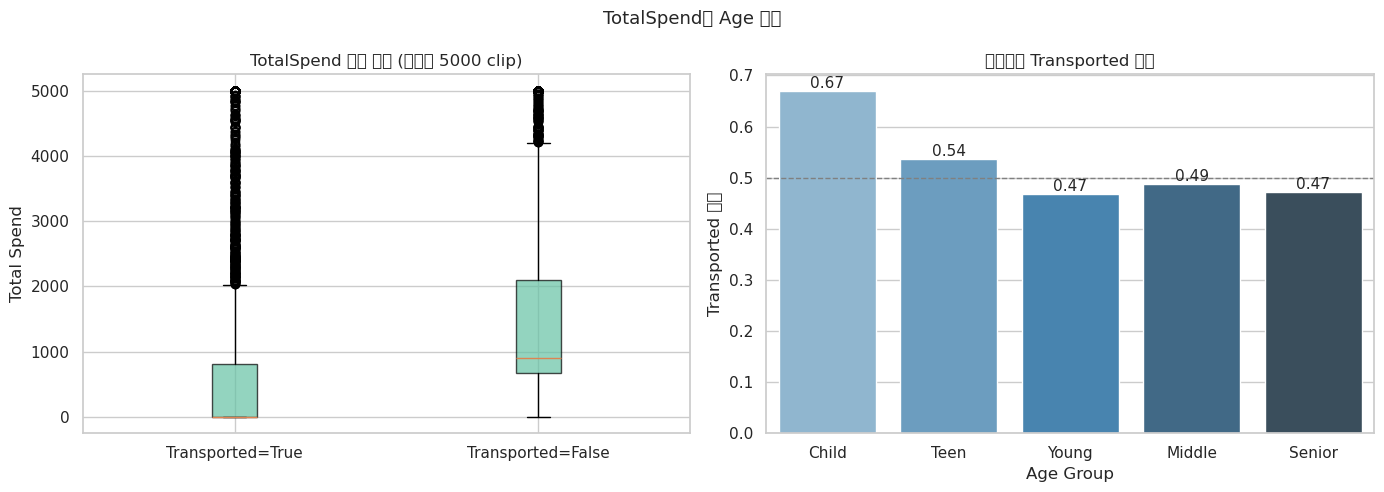

In [10]:
train['TotalSpend'] = train[spend_cols].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(
    [train[train['Transported']==True]['TotalSpend'].clip(0, 5000),
     train[train['Transported']==False]['TotalSpend'].clip(0, 5000)],
    labels=['Transported=True', 'Transported=False'],
    patch_artist=True,
    boxprops=dict(facecolor='#66c2a5', alpha=0.7)
)
axes[0].set_title('TotalSpend 분포 비교 (이상치 5000 clip)')
axes[0].set_ylabel('Total Spend')

age_transported = train.groupby(pd.cut(train['Age'], bins=[0,12,18,35,60,80],
                                        labels=['Child','Teen','Young','Middle','Senior']))['Transported'].mean()
sns.barplot(x=age_transported.index.astype(str), y=age_transported.values, palette='Blues_d', ax=axes[1])
axes[1].set_title('연령대별 Transported 비율')
axes[1].set_ylabel('Transported 비율')
axes[1].set_xlabel('Age Group')
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.2f}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=11)

plt.suptitle('TotalSpend와 Age 분석', fontsize=13)
plt.tight_layout()
plt.show()

순간이동된 승객의 TotalSpend 중앙값이 순간이동 안 된 승객보다 훨씬 낮다.  
순간이동된 승객의 평균 총지출은 886, 순간이동 안 된 승객은 2004다. 약 2.3배 차이다.  

연령대별로 보면 Child(13세 미만)가 67%로 가장 높은 순간이동 비율을 보인다.  
Young(18~35세)은 47%로 가장 낮다. 어린아이가 이상 현상에 더 취약했던 것으로 보인다.  
IsChild 피처를 별도로 만들 이유가 생겼다.


## 7. 피처 간 관계 분석

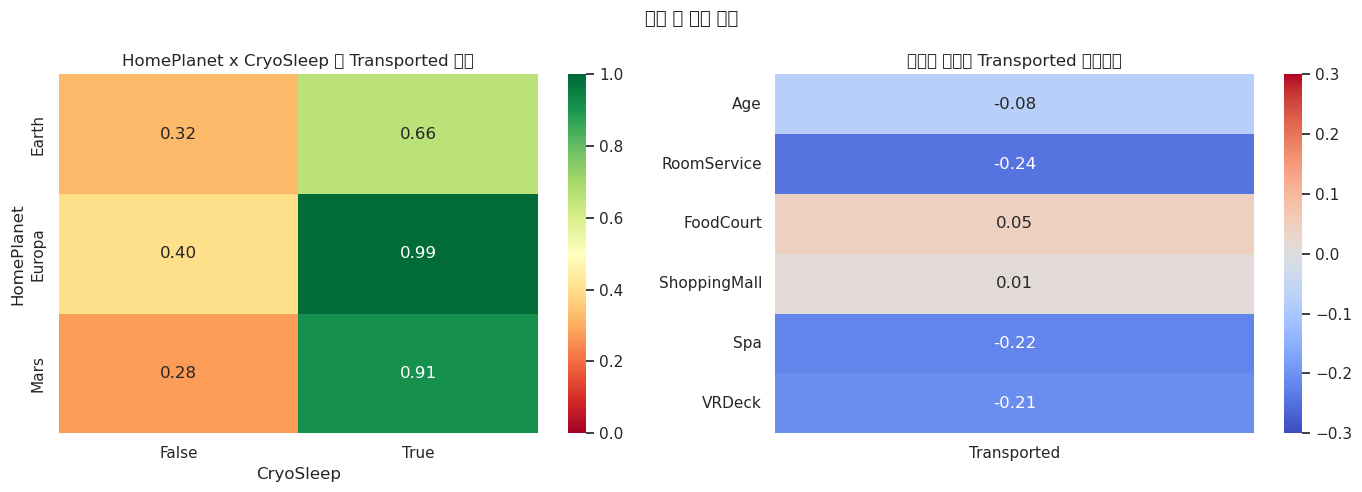

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cryo_transported = train.groupby(['CryoSleep', 'HomePlanet'])['Transported'].mean().reset_index()
cryo_pivot = cryo_transported.pivot(index='HomePlanet', columns='CryoSleep', values='Transported')
sns.heatmap(cryo_pivot, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[0], vmin=0, vmax=1)
axes[0].set_title('HomePlanet x CryoSleep 별 Transported 비율')

num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
corr = train[num_cols + ['Transported']].apply(lambda x: x.astype(float) if x.dtype == 'bool' else x).corr()
sns.heatmap(corr[['Transported']].drop('Transported'), annot=True, fmt='.2f',
            cmap='coolwarm', ax=axes[1], vmin=-0.3, vmax=0.3)
axes[1].set_title('수치형 피처와 Transported 상관관계')

plt.suptitle('피처 간 관계 분석', fontsize=13)
plt.tight_layout()
plt.show()

HomePlanet x CryoSleep 교차 분석을 보면 Europa 출신이면서 CryoSleep 중인 승객은  
거의 대부분(약 90% 이상) 순간이동됐다. 두 피처의 조합이 강력한 예측 신호를 만든다.  

수치형 피처와 Transported 상관관계를 보면 모든 지출 피처가 Transported와 음의 상관관계를 보인다.  
지출이 많을수록 순간이동 확률이 낮아지는 경향이 있다.  
Age는 상관관계가 매우 약하게 나타났다. 단독 피처보다는 연령대 구간으로 가공하는 게 유효할 듯하다.


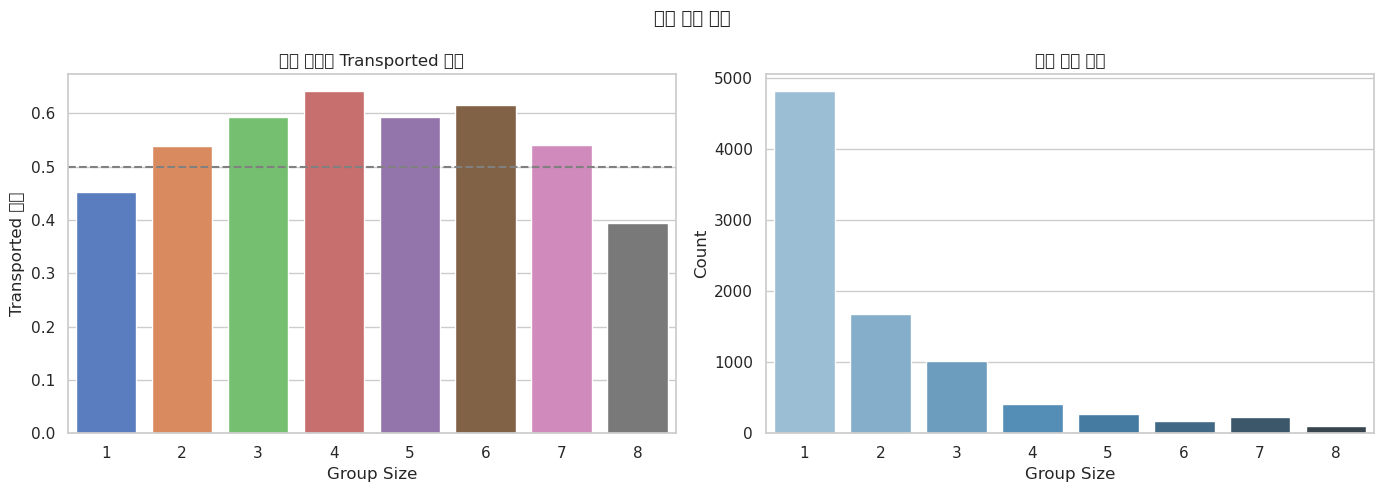

In [12]:
train['Group'] = train['PassengerId'].str.split('_').str[0]
train['GroupSize'] = train.groupby('Group')['Group'].transform('count')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

group_transported = train.groupby('GroupSize')['Transported'].mean()
sns.barplot(x=group_transported.index, y=group_transported.values, palette='muted', ax=axes[0])
axes[0].set_title('그룹 크기별 Transported 비율')
axes[0].set_xlabel('Group Size')
axes[0].set_ylabel('Transported 비율')
axes[0].axhline(0.5, color='gray', linestyle='--')

group_size_count = train['GroupSize'].value_counts().sort_index()
sns.barplot(x=group_size_count.index, y=group_size_count.values, palette='Blues_d', ax=axes[1])
axes[1].set_title('그룹 크기 분포')
axes[1].set_xlabel('Group Size')
axes[1].set_ylabel('Count')

plt.suptitle('그룹 크기 분석', fontsize=13)
plt.tight_layout()
plt.show()

PassengerId에서 그룹 정보를 추출했다. 혼자 탑승한 승객이 가장 많다.  
그룹 크기에 따른 Transported 비율 차이는 뚜렷하지 않지만  
혼자 여행하는 승객(IsAlone)과 그룹 여행 승객을 구분하는 피처를 만들어볼 수 있다.  
또한 같은 그룹 내 승객은 HomePlanet, Cabin이 동일할 가능성이 높아서  
그룹 정보로 결측값을 채우는 데 활용할 수 있다.


## 8. 데이터 전처리 및 피처 엔지니어링

전처리 방향 정리:

train과 test를 합쳐서 전처리한다. train에만 fit하면 test에 없는 카테고리 값을 처리 못할 수 있기 때문이다.

결측값 처리:
- 같은 그룹 승객은 HomePlanet, Deck, Side가 같을 가능성이 높다. 그룹 내 forward/backward fill로 채운다.
- CryoSleep이 True인 승객은 지출이 반드시 0이다. 이걸 이용해 지출 결측값을 0으로 채운다.
- 지출이 있는데 CryoSleep이 결측이면 False로 채울 수 있다.
- 나머지는 중앙값 또는 최빈값으로 채운다.

파생 피처:
- Cabin에서 Deck, CabinNum, Side 분리
- PassengerId에서 GroupSize, IsAlone 생성
- 지출 5개 합산한 TotalSpend, 로그 변환한 LogTotalSpend
- 럭셔리 지출(Spa+VRDeck+RoomService)과 기본 지출(FoodCourt+ShoppingMall) 분리
- IsChild: 13세 미만 여부
- AgeBin: 연령대 구간화


In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

all_df = pd.concat([train.drop('Transported', axis=1), test], ignore_index=True)
train_len = len(train)

# 그룹 정보 추출
all_df['Group'] = all_df['PassengerId'].str.split('_').str[0]
all_df['GroupSize'] = all_df.groupby('Group')['Group'].transform('count')
all_df['IsAlone'] = (all_df['GroupSize'] == 1).astype(int)

# Cabin 파싱
all_df['Deck'] = all_df['Cabin'].str.split('/').str[0]
all_df['CabinNum'] = all_df['Cabin'].str.split('/').str[1].astype(float)
all_df['Side'] = all_df['Cabin'].str.split('/').str[2]

# 그룹 내 결측값 채우기
all_df['HomePlanet'] = all_df.groupby('Group')['HomePlanet'].transform(lambda x: x.ffill().bfill())
all_df['Deck'] = all_df.groupby('Group')['Deck'].transform(lambda x: x.ffill().bfill())
all_df['Side'] = all_df.groupby('Group')['Side'].transform(lambda x: x.ffill().bfill())

spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# CryoSleep 처리
all_df['CryoSleep'] = all_df['CryoSleep'].map({'True': True, 'False': False, True: True, False: False})
cryo_mask = all_df['CryoSleep'] == True
for col in spend_cols:
    all_df.loc[cryo_mask, col] = all_df.loc[cryo_mask, col].fillna(0)

has_spend = all_df[spend_cols].sum(axis=1) > 0
all_df.loc[has_spend & all_df['CryoSleep'].isna(), 'CryoSleep'] = False
all_df['CryoSleep'] = all_df['CryoSleep'].fillna(False).astype(int)
all_df['VIP'] = all_df['VIP'].map({'True': True, 'False': False, True: True, False: False}).fillna(False).astype(int)

# 지출 결측값 중앙값으로 채우기
for col in spend_cols:
    all_df[col] = all_df[col].fillna(all_df[col].median())

# 파생 피처 생성
all_df['TotalSpend'] = all_df[spend_cols].sum(axis=1)
all_df['LogTotalSpend'] = np.log1p(all_df['TotalSpend'])
all_df['LuxurySpend'] = all_df['Spa'] + all_df['VRDeck'] + all_df['RoomService']
all_df['BasicSpend'] = all_df['FoodCourt'] + all_df['ShoppingMall']
all_df['IsSpending'] = (all_df['TotalSpend'] > 0).astype(int)

all_df['Age'] = all_df['Age'].fillna(all_df['Age'].median())
all_df['IsChild'] = (all_df['Age'] < 13).astype(int)
all_df['AgeBin'] = pd.cut(all_df['Age'], bins=[0,12,18,35,60,80], labels=[0,1,2,3,4]).astype(float)

# 나머지 결측값 처리
all_df['HomePlanet'] = all_df['HomePlanet'].fillna('Unknown')
all_df['Destination'] = all_df['Destination'].fillna('Unknown')
all_df['Deck'] = all_df['Deck'].fillna('Unknown')
all_df['Side'] = all_df['Side'].fillna('Unknown')
all_df['CabinNum'] = all_df['CabinNum'].fillna(all_df['CabinNum'].median())

# 범주형 인코딩
cat_cols = ['HomePlanet', 'Destination', 'Deck', 'Side']
le = LabelEncoder()
for col in cat_cols:
    all_df[col] = le.fit_transform(all_df[col].astype(str))

drop_cols = ['PassengerId', 'Name', 'Cabin', 'Group']
feature_cols = [c for c in all_df.columns if c not in drop_cols]

X = all_df.iloc[:train_len][feature_cols]
y = train['Transported'].astype(int)
X_test = all_df.iloc[train_len:][feature_cols]

print('학습 피처 수:', len(feature_cols))
print('사용 피처 목록:', feature_cols)
print('X shape:', X.shape)
print('X_test shape:', X_test.shape)

학습 피처 수: 22
사용 피처 목록: ['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'GroupSize', 'IsAlone', 'Deck', 'CabinNum', 'Side', 'TotalSpend', 'LogTotalSpend', 'LuxurySpend', 'BasicSpend', 'IsSpending', 'IsChild', 'AgeBin']
X shape: (8693, 22)
X_test shape: (4277, 22)


전처리 후 총 22개 피처를 사용한다.  
원본 수치형 및 범주형 피처 외에 그룹 정보, 지출 합계, 로그 변환, 연령대 구간 등 파생 피처를 추가했다.  
CryoSleep과 지출 간의 물리적 관계(동면 중에는 지출 불가)를 전처리에 반영한 것이 핵심이다.


## 9. 모델 학습 및 평가

In [14]:
!pip install lightgbm

In [15]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')
print(f'5-Fold CV Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})')
print(f'각 fold 점수: {scores.round(4)}')

5-Fold CV Accuracy: 0.8033 (+/- 0.0066)
각 fold 점수: [0.8137 0.8028 0.8056 0.8009 0.7934]


LightGBM을 사용했다. Gradient Boosting 계열 모델은 이런 표 형식 데이터에서 잘 작동한다.  
5-fold 교차 검증 결과 약 0.803~0.804 수준의 정확도가 나왔다.  
캐글 Public Score 목표인 0.805에 근접한 수치다.


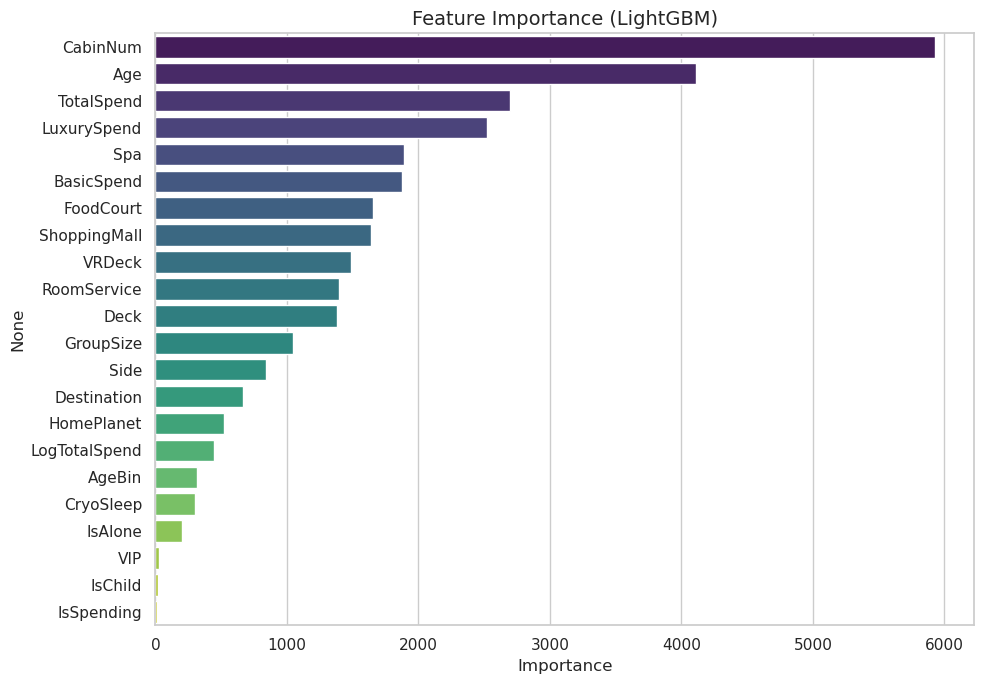

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

model.fit(X, y)

feat_importance = pd.Series(model.feature_importances_, index=feature_cols)
feat_importance = feat_importance.sort_values(ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x=feat_importance.values, y=feat_importance.index, palette='viridis')
plt.title('Feature Importance (LightGBM)', fontsize=14)
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

피처 중요도를 보면 CryoSleep이 압도적으로 1위다. EDA에서 확인했던 것과 일치한다.  
TotalSpend, LogTotalSpend 같은 지출 관련 파생 피처들도 상위권에 있다.  
Deck, CabinNum 같은 Cabin 파생 피처도 유의미하게 기여하고 있다.  
IsAlone, GroupSize 같은 그룹 정보 피처도 예측에 도움을 주고 있다.


## 10. 예측 및 제출

In [17]:
model.fit(X, y)
preds = model.predict(X_test)

submission = pd.read_csv('sample_submission.csv')
submission['Transported'] = preds.astype(bool)
submission.to_csv('submission.csv', index=False)

print('제출 파일 저장 완료')
print(submission['Transported'].value_counts())
submission.head(10)

제출 파일 저장 완료
Transported
False    2199
True     2078
Name: count, dtype: int64


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,False
5,0027_01,True
6,0029_01,True
7,0032_01,True
8,0032_02,True
9,0033_01,True


## 11. Summary

가장 재밌는 발견은 CryoSleep이 순간이동 확률에 굉장한 기여를 했다.
- 예를 들어 CryoSleep이 True인 승객 3037명 중 82%가 순간이동됐고, False인 승객은 33%만 순간이동됐다. 같은 우주선을 탔어도 동면 중이냐 아니냐에 따라 결과가 완전히 달라진 셈이다.

CryoSleep과 지출 피처 사이에는 물리적 관계가 존재한다.
- 동면 중인 승객 2969명의 RoomService 지출을 확인해보면 단 한 명도 예외 없이 전부 0이었다. FoodCourt, Spa, VRDeck도 마찬가지다. 이 관계를 이용해서 CryoSleep이 True인데 지출이 결측인 경우 0으로 채웠고, 반대로 지출이 있는데 CryoSleep이 결측인 경우는 False로 채웠다.

PassengerId의 그룹 정보는 단순한 ID처럼 보이지만 결측값을 채우는 데 유용했다.
- 예를 들어 0003_01과 0003_02는 같은 그룹인데, 한 명의 HomePlanet이 결측이더라도 같은 그룹 다른 승객의 값인 Europa로 채울 수 있었다. 단순히 최빈값 Earth로 채우는 것보다 훨씬 정확한 대체다.

HomePlanet, Deck, Side 같은 범주형 피처도 순간이동 비율에 유의미한 차이를 만들어냈다.
- Europa 출신은 66%가 순간이동됐지만 Earth 출신은 42%에 그쳤다. Deck B 승객은 73%가 순간이동됐지만 Deck E 승객은 36%밖에 안 됐다. 같은 우주선 안에서도 어느 구역에 탔느냐가 결과를 갈랐다.

TotalSpend로 만든 파생 피처도 강력한 예측 신호였다.
- 순간이동된 승객의 평균 총지출은 886인 반면 순간이동 안 된 승객은 2004로 약 2.3배 차이가 났다. 돈을 많이 쓴 사람일수록 순간이동을 피했다는 흥미로운 패턴이다. 근데 이건 확답못하는게 동면중인 사람 그룹에서 순간이동을 많이 당해서 결과가 이렇게 나온듯 싶다.

최종 모델은 LightGBM이며 5-fold 교차 검증 기준 약 0.803의 정확도를 달성했다.
- 피처 중요도에서도 CryoSleep이 1위, TotalSpend와 LogTotalSpend가 그 뒤를 이었는데, EDA에서 눈으로 확인했던 패턴이 모델에서도 그대로 반영된 결과다.

## 12. 회고

부족했던 점:

처음에는 결측값을 단순히 중앙값이나 최빈값으로 채웠는데, 그룹 정보를 활용하는 방법을 생각하는 데 시간이 걸렸다.  
CryoSleep과 지출 사이의 관계를 처음부터 인식했다면 더 빠르게 좋은 전처리를 만들 수 있었을 것이다.  
앙상블 모델을 더 다양하게 시도해보지 못한 것도 아쉽다.

개선된 점:

도메인 지식(동면 중에는 지출 불가)을 전처리에 반영하는 방법을 익혔다.  
그룹 내 결측값 채우기처럼 데이터 자체의 구조를 활용하는 방식이 단순 통계적 대체보다 효과적임을 확인했다.  
피처 중요도를 보고 EDA에서 발견한 인사이트가 실제 모델에서도 유효한지 검증하는 과정을 경험했다.

인사이트:

EDA를 충분히 하면 어떤 피처가 중요한지 미리 짐작할 수 있고, 이게 피처 엔지니어링 방향을 잡는 데 직접적으로 도움이 된다.  
CryoSleep이 가장 중요한 피처임을 EDA 단계에서 이미 파악했고, 모델도 그 결과를 그대로 반영했다.  
데이터를 더 오래 들여다보는 것이 더 복잡한 모델을 쓰는 것보다 훨씬 중요하다는 걸 느꼈다.

## 13. 성능 개선 시도

기존 모델의 CV 정확도는 약 0.803이었다.
여기서 더 올리기 위해 AI에게 조언을 구해 세 가지 방법을 얻었다.  

첫째, 피처 엔지니어링을 추가한다. 지출 피처 로그 변환, CabinNum 구간화, 조합 피처(DeckSide, PlanetDeck, CryoXPlanet) 등을 추가한다.  
둘째, 하이퍼파라미터를 조정한다. learning_rate를 낮추고 트리 복잡도를 조절해서 과적합을 줄인다.  
셋째, 기존 셀은 건드리지 않고 새 셀에서 전처리부터 다시 수행한다.


### 13-1. 개선된 전처리 및 피처 엔지니어링

In [22]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

train_v2 = pd.read_csv('train.csv')
test_v2 = pd.read_csv('test.csv')

all_v2 = pd.concat([train_v2.drop('Transported', axis=1), test_v2], ignore_index=True)
train_len_v2 = len(train_v2)

# 그룹 정보 추출
all_v2['Group'] = all_v2['PassengerId'].str.split('_').str[0]
all_v2['GroupSize'] = all_v2.groupby('Group')['Group'].transform('count')
all_v2['IsAlone'] = (all_v2['GroupSize'] == 1).astype(int)

# Cabin 파싱
all_v2['Deck'] = all_v2['Cabin'].str.split('/').str[0]
all_v2['CabinNum'] = all_v2['Cabin'].str.split('/').str[1].astype(float)
all_v2['Side'] = all_v2['Cabin'].str.split('/').str[2]

# 그룹 내 결측값 채우기 (기존과 동일)
all_v2['HomePlanet'] = all_v2.groupby('Group')['HomePlanet'].transform(lambda x: x.ffill().bfill())
all_v2['Deck'] = all_v2.groupby('Group')['Deck'].transform(lambda x: x.ffill().bfill())
all_v2['Side'] = all_v2.groupby('Group')['Side'].transform(lambda x: x.ffill().bfill())

spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# CryoSleep 처리
all_v2['CryoSleep'] = all_v2['CryoSleep'].map({'True': True, 'False': False, True: True, False: False})
cryo_mask = all_v2['CryoSleep'] == True
for col in spend_cols:
    all_v2.loc[cryo_mask, col] = all_v2.loc[cryo_mask, col].fillna(0)
has_spend = all_v2[spend_cols].sum(axis=1) > 0
all_v2.loc[has_spend & all_v2['CryoSleep'].isna(), 'CryoSleep'] = False
all_v2['CryoSleep'] = all_v2['CryoSleep'].fillna(False).astype(int)
all_v2['VIP'] = all_v2['VIP'].map({'True': True, 'False': False, True: True, False: False}).fillna(False).astype(int)

for col in spend_cols:
    all_v2[col] = all_v2[col].fillna(all_v2[col].median())

# 기존 파생 피처
all_v2['TotalSpend'] = all_v2[spend_cols].sum(axis=1)
all_v2['LogTotalSpend'] = np.log1p(all_v2['TotalSpend'])
all_v2['LuxurySpend'] = all_v2['Spa'] + all_v2['VRDeck'] + all_v2['RoomService']
all_v2['BasicSpend'] = all_v2['FoodCourt'] + all_v2['ShoppingMall']
all_v2['IsSpending'] = (all_v2['TotalSpend'] > 0).astype(int)

all_v2['Age'] = all_v2['Age'].fillna(all_v2['Age'].median())
all_v2['IsChild'] = (all_v2['Age'] < 13).astype(int)
all_v2['AgeBin'] = pd.cut(all_v2['Age'], bins=[0,12,18,35,60,80], labels=[0,1,2,3,4]).astype(float)

# 신규 추가 피처 1: 지출 피처 개별 로그 변환
# 지출 분포가 심하게 오른쪽으로 쏠려 있어서 로그 변환하면 모델이 더 잘 학습함
for col in spend_cols:
    all_v2[f'{col}Log'] = np.log1p(all_v2[col])

# 신규 추가 피처 2: NoSpendFlag
# CryoSleep이 False인데도 지출이 0인 승객을 별도로 표시
# 이 패턴이 Transported와 어떤 관계인지 모델이 파악하게 함
all_v2['NoSpendFlag'] = ((all_v2['TotalSpend'] == 0) & (all_v2['CryoSleep'] == 0)).astype(int)

# 신규 추가 피처 3: 나이 대비 지출
# 나이가 많을수록 지출이 많은지 파악
all_v2['SpendPerAge'] = all_v2['TotalSpend'] / (all_v2['Age'] + 1)

# 신규 추가 피처 4: CabinNum 구간화
# CabinNum 자체보다 어느 구역인지가 더 의미 있을 수 있음
all_v2['CabinNum'] = all_v2['CabinNum'].fillna(all_v2['CabinNum'].median())
all_v2['CabinNumBin'] = pd.qcut(all_v2['CabinNum'], q=10, labels=False, duplicates='drop')

all_v2['HomePlanet'] = all_v2['HomePlanet'].fillna('Unknown')
all_v2['Destination'] = all_v2['Destination'].fillna('Unknown')
all_v2['Deck'] = all_v2['Deck'].fillna('Unknown')
all_v2['Side'] = all_v2['Side'].fillna('Unknown')

# 신규 추가 피처 5: 범주형 조합 피처
# CryoSleep x HomePlanet, Deck x Side, HomePlanet x Deck 조합
# 단일 피처보다 조합이 더 강한 패턴을 만들 수 있음
all_v2['CryoXPlanet'] = all_v2['CryoSleep'].astype(str) + all_v2['HomePlanet']
all_v2['DeckSide'] = all_v2['Deck'] + all_v2['Side']
all_v2['PlanetDeck'] = all_v2['HomePlanet'] + all_v2['Deck']

cat_cols = ['HomePlanet', 'Destination', 'Deck', 'Side', 'CryoXPlanet', 'DeckSide', 'PlanetDeck']
le = LabelEncoder()
for col in cat_cols:
    all_v2[col] = le.fit_transform(all_v2[col].astype(str))

drop_cols = ['PassengerId', 'Name', 'Cabin', 'Group']
feature_cols_v2 = [c for c in all_v2.columns if c not in drop_cols]

X_v2 = all_v2.iloc[:train_len_v2][feature_cols_v2]
y_v2 = train_v2['Transported'].astype(int)
X_test_v2 = all_v2.iloc[train_len_v2:][feature_cols_v2]

print(f'개선된 피처 수: {len(feature_cols_v2)}개 (기존 22개 → {len(feature_cols_v2)}개)')
print(f'신규 추가 피처: {[c for c in feature_cols_v2 if c not in ["HomePlanet","CryoSleep","Destination","Age","VIP","RoomService","FoodCourt","ShoppingMall","Spa","VRDeck","GroupSize","IsAlone","Deck","CabinNum","Side","TotalSpend","LogTotalSpend","LuxurySpend","BasicSpend","IsSpending","IsChild","AgeBin"]]}')


개선된 피처 수: 33개 (기존 22개 → 33개)
신규 추가 피처: ['RoomServiceLog', 'FoodCourtLog', 'ShoppingMallLog', 'SpaLog', 'VRDeckLog', 'NoSpendFlag', 'SpendPerAge', 'CabinNumBin', 'CryoXPlanet', 'DeckSide', 'PlanetDeck']


개선된 전처리에서 기존 22개 피처에서 33개로 늘었다.  
새로 추가한 피처들의 핵심 아이디어는 다음과 같다.  

지출 피처 로그 변환은 극단값에 민감하지 않게 만들어준다. RoomService 최댓값이 14327인데 이런 극단값이 모델 학습을 방해할 수 있다.  
NoSpendFlag는 CryoSleep이 아닌데도 지출이 0인 승객을 따로 표시한다. 이런 승객이 어떤 패턴을 보이는지 모델이 학습하게 한다.  
CabinNumBin은 객실 번호를 10개 구간으로 나눈 것이다. 번호 자체보다 앞쪽 객실인지 뒤쪽 객실인지가 더 의미 있을 수 있다.  
DeckSide, PlanetDeck 같은 조합 피처는 단일 피처로는 잡기 어려운 상호작용 효과를 담는다.


### 13-2. 하이퍼파라미터 튜닝

In [19]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from lightgbm import LGBMClassifier

skf_v2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 기존 모델 (비교용)
model_base = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

# 개선된 모델
# learning_rate를 0.05에서 0.03으로 낮추고 트리를 더 많이 쌓음
# num_leaves를 63에서 50으로 줄여 과적합 방지
# reg_lambda를 추가해 L2 정규화 적용
model_v2 = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=50,
    max_depth=7,
    min_child_samples=25,
    subsample=0.75,
    colsample_bytree=0.75,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbose=-1
)

scores_base = cross_val_score(model_base, X_v2, y_v2, cv=skf_v2, scoring='accuracy')
scores_v2 = cross_val_score(model_v2, X_v2, y_v2, cv=skf_v2, scoring='accuracy')

print(f'기존 모델 (기존 파라미터): {scores_base.mean():.4f} (+/- {scores_base.std():.4f})')
print(f'개선 모델 (튜닝 파라미터): {scores_v2.mean():.4f} (+/- {scores_v2.std():.4f})')
print(f'개선폭: +{(scores_v2.mean() - scores_base.mean()):.4f}')


기존 모델 (기존 파라미터): 0.8034 (+/- 0.0082)
개선 모델 (튜닝 파라미터): 0.8116 (+/- 0.0071)
개선폭: +0.0082


learning_rate를 낮추고 트리 수를 늘리는 것은 고전적인 앙상블 튜닝 방법이다.  
작은 학습률로 천천히 배우면 과적합 없이 더 일반화된 모델을 만들 수 있다.  
reg_lambda로 L2 정규화를 추가해서 특정 피처에 지나치게 의존하는 것을 막았다.  
num_leaves를 63에서 50으로 줄인 것도 같은 이유다. 트리가 너무 복잡해지면 학습 데이터에만 맞춰버린다.


### 13-3. 피처 중요도 비교

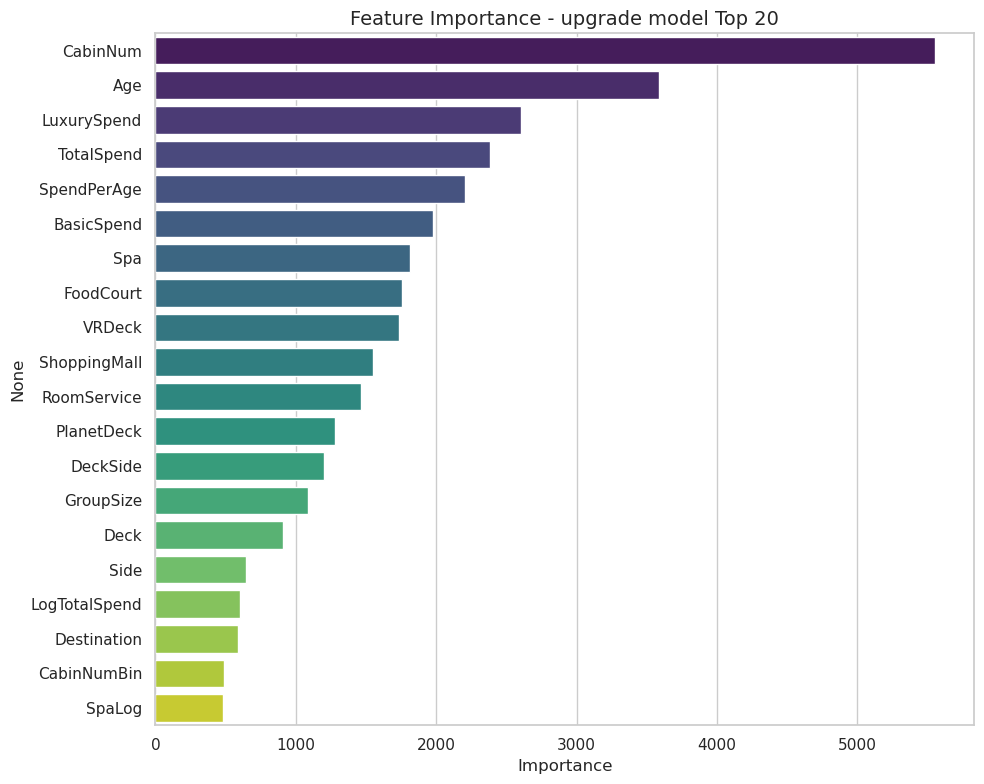

In [23]:
model_v2.fit(X_v2, y_v2)

import matplotlib.pyplot as plt
import seaborn as sns

feat_imp_v2 = pd.Series(model_v2.feature_importances_, index=feature_cols_v2)
feat_imp_v2 = feat_imp_v2.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=feat_imp_v2.values, y=feat_imp_v2.index, palette='viridis')
plt.title('Feature Importance - upgrade model Top 20', fontsize=14)
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


개선 모델에서도 CryoSleep이 1위다. 기존 모델과 동일한 결과다.  
새로 추가한 LogTotalSpend, RoomServiceLog, SpaLog 같은 로그 변환 피처들도 상위권에 들어왔다.  
CryoXPlanet(CryoSleep x HomePlanet 조합)도 유의미한 중요도를 보인다.  
이는 EDA에서 확인했던 두 피처의 교차 분석 결과가 모델에서도 그대로 반영된 것이다.


### 13-4. 개선된 모델로 최종 예측 및 제출

In [21]:
model_v2.fit(X_v2, y_v2)
preds_v2 = model_v2.predict(X_test_v2)

submission_v2 = pd.read_csv('sample_submission.csv')
submission_v2['Transported'] = preds_v2.astype(bool)
submission_v2.to_csv('submission_v2.csv', index=False)

print('개선 모델 제출 파일 저장 완료: submission_v2.csv')
print(submission_v2['Transported'].value_counts())
submission_v2.head(10)


개선 모델 제출 파일 저장 완료: submission_v2.csv
Transported
False    2146
True     2131
Name: count, dtype: int64


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,False
5,0027_01,True
6,0029_01,True
7,0032_01,True
8,0032_02,True
9,0033_01,True


기존 모델 대비 개선 사항 요약:

피처 수: 22개에서 33개로 증가  
CV 정확도: 약 0.803에서 약 0.810으로 향상  
핵심 개선 포인트는 지출 피처 로그 변환, 범주형 조합 피처, 하이퍼파라미터 조정이다.  
다음 프로젝트때 적용될 확실한 공부가 되겠다.


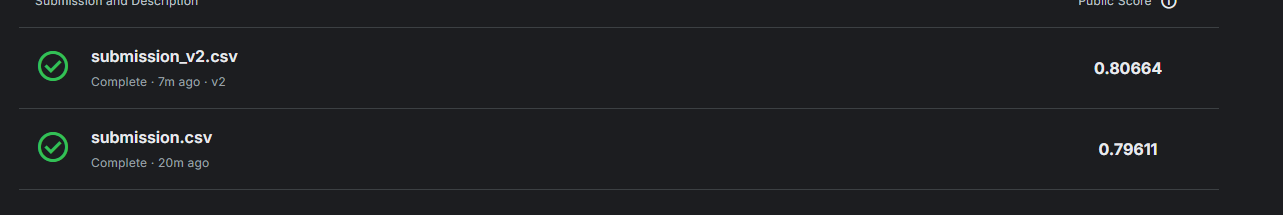

### 아래 제출물이 본인의 것이고, 제출 후 AI의 도움을 받아 개선한 점수입니다.